<a href="https://colab.research.google.com/github/ALSO-Space/CMEMS-DatavizProposal/blob/main/SSTGraph_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily global sea surface temperature — annotated reference layout

This Google Colab notebook reproduces `SST timeseries_11June.png` using external ESA CCI and Copernicus Marine GLO12 daily SST files, Gotham Book, and two composite logo assets stored in Google Drive.

The final graphic includes the data-source line, direct year labels, the 1991–2022 historical label, and the institutional logo strip. The export remains fixed at **4962 × 3507 pixels, 300 DPI**; the notebook preview is displayed at one-third width.

All source files are read directly from Google Drive and remain unchanged.


## 1. Colab environment

Colab already includes most required libraries. The installation cell pins only the small set used by this workflow and keeps the runtime reproducible.


In [107]:
# Install the libraries used by the notebook.
!pip install -q pandas matplotlib numpy pillow


In [108]:
# Import the analysis, plotting, and file-management libraries.
import os
import shutil
import warnings
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display, Image as IPythonImage
from PIL import Image

warnings.filterwarnings("default")
print("Libraries loaded.")


Libraries loaded.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Google Drive and project folders

The folder structure mirrors the persistent Drive workflow used by the Sea Ice notebook. Source CSV files are retained in `ClimateCharts/sst_data/04_sst`, while figures are written to `ClimateCharts/figure/04_sst`.


In [109]:
# Mount Google Drive and create persistent project folders.
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = Path('/content/drive/MyDrive/ClimateCharts')
DATA_DIR = BASE_DIR / 'sst_data' / '04_sst'
OUTPUT_DIR = BASE_DIR / 'figure' / '04_sst'

for folder in (DATA_DIR, OUTPUT_DIR):
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Ready: {folder}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready: /content/drive/MyDrive/ClimateCharts/sst_data/04_sst
Ready: /content/drive/MyDrive/ClimateCharts/figure/04_sst


## Data provenance

The historical context uses the processed global daily mean SST series from ESA CCI. GLO12 supplies the recent series from 2021 onwards. The two products are joined at a fixed transition year without numerical bias correction; this should be stated when the graphic is published.

Rows with missing SST are removed automatically. The source CSV files remain external and unchanged.


## 3. Fixed input configuration

Place these files in `MyDrive/ClimateCharts/sst_data/04_sst/`:

- `esacci_SST_global.csv`
- `daily_mean_SST_GLO12_global_level0_from_20210101_to_20261231.csv`
- `Gotham-Book.otf`
- `NewCopernicusLogoBlue.png` — EU Programme and Copernicus
- `CMEMS_MOi.png` — Copernicus Marine Service and Mercator Ocean International

Transparent PNG files with tightly cropped bounds produce the closest match. The notebook trims residual transparent or white margins automatically.


In [110]:
# ----------------------------- FIXED CONFIGURATION -----------------------------
REGION_LABEL = 'Global ocean'
REGION_SLUG = 'global'

ESACCI_FILENAME = 'esacci_SST_global.csv'
GLO12_FILENAME = 'daily_mean_SST_GLO12_global_level0_from_20210101_to_20261231.csv'
ESACCI_PATH = DATA_DIR / ESACCI_FILENAME
GLO12_PATH = DATA_DIR / GLO12_FILENAME
CUSTOM_FONT_PATH = DATA_DIR / 'Gotham-Book.otf'

COPERNICUS_PROGRAMME_LOGO_PATH = DATA_DIR / 'NewCopernicusLogoBlue.png'
CMEMS_MOI_LOGO_PATH = DATA_DIR / 'CMEMS_MOi.png'

HISTORICAL_START_YEAR = 1991
TRANSITION_YEAR = 2021
DATA_CUTOFF = pd.Timestamp('2026-06-11')

EXPORT_DPI = 300
A3_WIDTH_IN = 4962 / EXPORT_DPI
A3_HEIGHT_IN = 3507 / EXPORT_DPI
EXPORT_FORMATS = ('png', 'pdf', 'svg')
PREVIEW_SCALE = 7

Y_MIN = 19.75
Y_MAX = 21.28
Y_TICK_STEP = 0.2

HIGHLIGHT_YEARS = [2023, 2024, 2025, 2026]
ESACCI_SOURCE_LABEL = 'ESA CCI daily global mean SST'
GLO12_SOURCE_LABEL = 'Copernicus Marine GLO12 daily global mean SST'

# Figure-coordinate logo boxes: [left, bottom, width, height].
LOGO_LAYOUT = {
    COPERNICUS_PROGRAMME_LOGO_PATH: [0.030, 0.040, 0.218, 0.070],
    CMEMS_MOI_LOGO_PATH: [0.720, 0.035, 0.207, 0.082],
}
# ------------------------------------------------------------------------------

print(f'Export: 4962 × 3507 px at {EXPORT_DPI} DPI')
print(f'Notebook preview: 1/{PREVIEW_SCALE} export width')


Export: 4962 × 3507 px at 300 DPI
Notebook preview: 1/7 export width


## 4. Direct data loading and product transition

The notebook reads both CSV files from `MyDrive/ClimateCharts/sst_data/04_sst/`. ESA CCI contributes observations from 1991 through 2020; GLO12 contributes observations from 2021 onwards. GLO12 dates use day/month/year order. Duplicate dates are averaged within each product before the fixed transition is applied.


In [111]:
def standardise_sst(frame, source_label, dayfirst=False):
    """Return one clean daily SST record with a common schema."""
    df = frame.copy()
    df.columns = [str(column).strip().lower() for column in df.columns]

    date_candidates = [column for column in ('date', 'time', 'datetime') if column in df]
    sst_candidates = [
        column for column in ('sst', 'sea_surface_temperature', 'mean_sst')
        if column in df
    ]
    if not date_candidates or not sst_candidates:
        raise ValueError(
            f'{source_label}: expected a date/time column and an SST column; '
            f'found {list(df.columns)}'
        )

    df = df.rename(columns={date_candidates[0]: 'date', sst_candidates[0]: 'sst'})
    df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=dayfirst)
    df['sst'] = pd.to_numeric(df['sst'], errors='coerce')
    df = df[['date', 'sst']].dropna().copy()

    if not df.empty and df['sst'].median() > 100:
        df['sst'] = df['sst'] - 273.15
        print(f'{source_label}: converted kelvin to degrees Celsius.')

    duplicate_count = int(df.duplicated('date').sum())
    if duplicate_count:
        print(f'{source_label}: averaging {duplicate_count} duplicate date rows.')
    df = df.groupby('date', as_index=False)['sst'].mean().sort_values('date')
    df['source'] = source_label
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['date_fixed'] = pd.to_datetime({
        'year': np.full(len(df), 2000),
        'month': df['month'],
        'day': df['day'],
    })
    return df.reset_index(drop=True)


def combine_sources(esacci, glo12):
    """Join ESA CCI history and GLO12 recent observations at 2021."""
    historical = esacci[
        esacci['year'].between(HISTORICAL_START_YEAR, TRANSITION_YEAR - 1)
    ].copy()
    recent = glo12[glo12['year'] >= TRANSITION_YEAR].copy()

    if historical.empty:
        raise ValueError(
            f'ESA CCI contains no valid observations for '
            f'{HISTORICAL_START_YEAR}–{TRANSITION_YEAR - 1}.'
        )
    if recent.empty:
        raise ValueError(f'GLO12 contains no valid observations from {TRANSITION_YEAR}.')

    return (
        pd.concat([historical, recent], ignore_index=True)
        .sort_values(['date', 'source'])
        .drop_duplicates('date', keep='last')
        .reset_index(drop=True)
    )


for required_path, label in (
    (ESACCI_PATH, 'ESA CCI CSV'),
    (GLO12_PATH, 'GLO12 CSV'),
):
    if not required_path.exists():
        raise FileNotFoundError(
            f'{label} not found. Place the file at this exact Google Drive path:\n'
            f'{required_path}'
        )

esacci = standardise_sst(pd.read_csv(ESACCI_PATH), ESACCI_SOURCE_LABEL, dayfirst=False)
glo12 = standardise_sst(pd.read_csv(GLO12_PATH), GLO12_SOURCE_LABEL, dayfirst=True)
combined = combine_sources(esacci, glo12)
combined = combined[combined['date'] <= DATA_CUTOFF].copy().reset_index(drop=True)

print(f'Plotted coverage: {combined.date.min():%d %b %Y}–{combined.date.max():%d %b %Y}')
print(f'Valid daily observations: {len(combined):,}')
display(
    combined.groupby('source')
    .agg(start=('date', 'min'), end=('date', 'max'), days=('date', 'size'))
)


/tmp/ipykernel_6932/457298808.py:18: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=dayfirst)


Plotted coverage: 01 Jan 1991–11 Jun 2026
Valid daily observations: 12,937


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,start,end,days
source,,,
Copernicus Marine GLO12 daily global mean SST,2021-01-01,2026-06-11,1987
ESA CCI daily global mean SST,1991-01-01,2020-12-31,10950


## Quality assurance

The following checks report temporal coverage, duplicate dates, physical-range warnings, missing days, and annual completeness. Missing future rows in the CSV do not enter the analysis because only valid SST observations are retained.


In [112]:
def quality_report(df):
    """Create compact coverage and continuity diagnostics."""
    if df['date'].duplicated().any():
        raise AssertionError('Duplicate dates remain in the cleaned record.')
    if not df['date'].is_monotonic_increasing:
        raise AssertionError('Dates are not sorted in ascending order.')

    implausible = df.loc[~df['sst'].between(-2.5, 40.0)]
    if len(implausible):
        warnings.warn(
            f'{len(implausible)} SST values fall outside the broad -2.5 to 40 °C check range.'
        )

    expected = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
    missing = expected.difference(pd.DatetimeIndex(df['date']))
    coverage = (
        df.groupby('year')
          .agg(start=('date', 'min'), end=('date', 'max'), days=('date', 'size'))
          .reset_index()
    )
    summary = pd.DataFrame({
        'metric': [
            'First valid date', 'Latest valid date', 'Valid observations',
            'Missing calendar days', 'Minimum SST (°C)', 'Maximum SST (°C)',
        ],
        'value': [
            df['date'].min().strftime('%d %b %Y'),
            df['date'].max().strftime('%d %b %Y'),
            f'{len(df):,}', f'{len(missing):,}',
            f"{df['sst'].min():.3f}", f"{df['sst'].max():.3f}",
        ],
    })
    return summary, coverage, missing


qa_summary, annual_coverage, missing_dates = quality_report(combined)
display(qa_summary)
display(annual_coverage)

if len(missing_dates):
    print('First missing dates:', ', '.join(d.strftime('%d %b %Y') for d in missing_dates[:10]))
else:
    print('No missing calendar days in the valid coverage period.')


,metric,value
0,First valid date,01 Jan 1991
1,Latest valid date,11 Jun 2026
2,Valid observations,"12,937"
3,Missing calendar days,9
4,Minimum SST (°C),19.824
5,Maximum SST (°C),21.213


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,year,start,end,days
0,1991,1991-01-01,1991-12-31,365
1,1992,1992-01-01,1992-12-31,365
2,1993,1993-01-01,1993-12-31,365
3,1994,1994-01-01,1994-12-31,365
4,1995,1995-01-01,1995-12-31,365
5,1996,1996-01-01,1996-12-31,365
6,1997,1997-01-01,1997-12-31,365
7,1998,1998-01-01,1998-12-31,365
8,1999,1999-01-01,1999-12-31,365
9,2000,2000-01-01,2000-12-31,365


First missing dates: 30 Dec 1992, 30 Dec 1996, 30 Dec 2000, 30 Dec 2004, 30 Dec 2008, 30 Dec 2012, 30 Dec 2016, 30 Dec 2020, 31 Dec 2024


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 5. Annotated reference composition

The plot area and footer strip use positions measured from the supplied reference. Historical trajectories remain neutral grey, recent years use the original warm palette, and all labels use Gotham Book. Logos are placed in figure coordinates so their alignment is independent of the data axes.


In [113]:
def configure_gotham(font_path=CUSTOM_FONT_PATH):
    """Register Gotham Book from Drive and return an explicit font property."""
    if not Path(font_path).exists():
        raise FileNotFoundError(
            'Gotham Book is required. Place the font at:\n'
            f'{font_path}'
        )

    font_manager.fontManager.addfont(str(font_path))
    font_prop = font_manager.FontProperties(fname=str(font_path))
    family = font_prop.get_name()
    mpl.rcParams.update({
        'font.family': family,
        'axes.unicode_minus': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'pdf.fonttype': 42,
        'svg.fonttype': 'path',
    })
    print(f'Using font: {family} ({font_path.name})')
    return font_prop


GOTHAM_PROP = configure_gotham()

missing_logos = [logo_path for logo_path in LOGO_LAYOUT if not logo_path.exists()]
if missing_logos:
    formatted = '\n'.join(str(logo_path) for logo_path in missing_logos)
    raise FileNotFoundError(f'Missing logo files:\n{formatted}')

YEAR_STYLES = {
    2023: dict(color='#FCCB6F', linewidth=1.6),
    2024: dict(color='#FB9374', linewidth=1.6),
    2025: dict(color='#E15662', linewidth=2.0),
    2026: dict(color='#810021', linewidth=2.6),
}

available_years = sorted(combined['year'].unique())
context_years = [year for year in available_years if year not in HIGHLIGHT_YEARS]
print(f"Context years: {', '.join(map(str, context_years))}")
print('All fonts and logos are available.')


Using font: Gotham (Gotham-Book.otf)
Context years: 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022
All fonts and logos are available.


In [114]:
def trimmed_logo_array(logo_path):
    """Load a logo and remove transparent or near-white outer margins."""
    with Image.open(logo_path) as image:
        rgba = np.asarray(image.convert('RGBA'))

    alpha = rgba[..., 3] > 8
    non_white = np.min(rgba[..., :3], axis=2) < 248
    visible = alpha & non_white
    rows, columns = np.where(visible)
    if len(rows) == 0 or len(columns) == 0:
        return rgba
    return rgba[rows.min():rows.max() + 1, columns.min():columns.max() + 1]


def add_logo(fig, logo_path, bounds):
    """Place one cropped logo inside a fixed figure-coordinate box."""
    logo_ax = fig.add_axes(bounds, zorder=20)
    logo_ax.imshow(trimmed_logo_array(logo_path), interpolation='lanczos')
    logo_ax.set_axis_off()
    logo_ax.set_anchor('C')
    return logo_ax


def plot_reference_sst(df):
    """Create the fully annotated A3 landscape SST graphic."""
    fig = plt.figure(figsize=(A3_WIDTH_IN, A3_HEIGHT_IN), dpi=EXPORT_DPI,
                     facecolor='white')
    ax = fig.add_axes([0.087, 0.185, 0.824, 0.777])
    ax.set_facecolor('white')
    ax.set_axisbelow(True)

    for year, group in df.groupby('year'):
        if year in HIGHLIGHT_YEARS:
            continue
        ax.plot(
            group['date_fixed'], group['sst'],
            color='#C1C0C0', linewidth=0.5, alpha=0.62, zorder=1,
        )

    for year in HIGHLIGHT_YEARS:
        group = df[df['year'] == year].sort_values('date_fixed')
        if group.empty:
            continue
        ax.plot(
            group['date_fixed'], group['sst'],
            solid_capstyle='round', zorder=2 + (year - HIGHLIGHT_YEARS[0]),
            **YEAR_STYLES[year],
        )

    ax.set_xlim(pd.Timestamp('2000-01-01'), pd.Timestamp('2000-12-31'))
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_yticks(np.arange(19.8, 21.21, Y_TICK_STEP))

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(
        axis='x', which='major', labelbottom=False,
        length=5, color='#777777', width=0.45,
    )
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonthday=15))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%b'))
    ax.tick_params(
        axis='x', which='minor', length=0,
        labelsize=18, pad=10, colors='#777777',
    )
    for label in ax.xaxis.get_minorticklabels():
        label.set_fontproperties(GOTHAM_PROP)
        label.set_fontsize(18)
        label.set_color('#777777')

    ax.tick_params(
        axis='y', which='major', length=5,
        color='#777777', width=0.5, labelsize=14, labelcolor='#777777',
    )
    for label in ax.get_yticklabels():
        label.set_fontproperties(GOTHAM_PROP)
        label.set_fontsize(14)
        label.set_color('#777777')

    ax.set_ylabel(
        'Sea Surface Temperature (°C)',
        fontproperties=GOTHAM_PROP, fontsize=16,
        color='#777777', labelpad=10,
    )

    ax.grid(False)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for spine in ('left', 'bottom'):
        ax.spines[spine].set_linewidth(0.5)
        ax.spines[spine].set_color('#777777')
        ax.spines[spine].set_alpha(0.65)

    # Reference annotations.
    fig.text(0.785, 0.955, 'Data: GLO12, ESA CCI',
             fontproperties=GOTHAM_PROP, fontsize=14,
             color='#777777', ha='left', va='top')
    ax.text(0.006, 0.090, '1991-2022', transform=ax.transAxes,
            fontproperties=GOTHAM_PROP, fontsize=16,
            color='#777777', ha='left', va='center')

    ax.text(pd.Timestamp('2000-06-03'), 20.985, '2026',
            fontproperties=GOTHAM_PROP, fontsize=18, fontweight='bold',
            color=YEAR_STYLES[2026]['color'], ha='left', va='center')
    ax.text(pd.Timestamp('2000-12-12'), 21.000, '2023',
            fontproperties=GOTHAM_PROP, fontsize=17,
            color=YEAR_STYLES[2023]['color'], ha='left', va='center')
    ax.text(pd.Timestamp('2000-12-14'), 20.780, '2024',
            fontproperties=GOTHAM_PROP, fontsize=17,
            color=YEAR_STYLES[2024]['color'], ha='left', va='center')
    ax.text(pd.Timestamp('2000-12-14'), 20.480, '2025',
            fontproperties=GOTHAM_PROP, fontsize=17,
            color=YEAR_STYLES[2025]['color'], ha='left', va='center')

    for logo_path, bounds in LOGO_LAYOUT.items():
        add_logo(fig, logo_path, bounds)

    return fig, ax


def export_reference_figure(fig):
    """Export the annotated figure without tight cropping or rescaling."""
    stem = 'SST timeseries_11June'
    paths = []
    for extension in EXPORT_FORMATS:
        output_path = OUTPUT_DIR / f'{stem}.{extension}'
        save_kwargs = {'facecolor': 'white'}
        if extension == 'png':
            save_kwargs['dpi'] = EXPORT_DPI
        fig.savefig(output_path, **save_kwargs)
        paths.append(output_path)
        print(f'Saved: {output_path}')
    return paths


## 6. Annotated A3 export and reduced preview

The PNG is saved at exactly 4962 × 3507 pixels and approximately 300 DPI. PDF and SVG preserve the same physical canvas. The notebook displays the completed PNG at one-third width.


Saved: /content/drive/MyDrive/ClimateCharts/figure/04_sst/SST timeseries_11June.png
Saved: /content/drive/MyDrive/ClimateCharts/figure/04_sst/SST timeseries_11June.pdf
Saved: /content/drive/MyDrive/ClimateCharts/figure/04_sst/SST timeseries_11June.svg


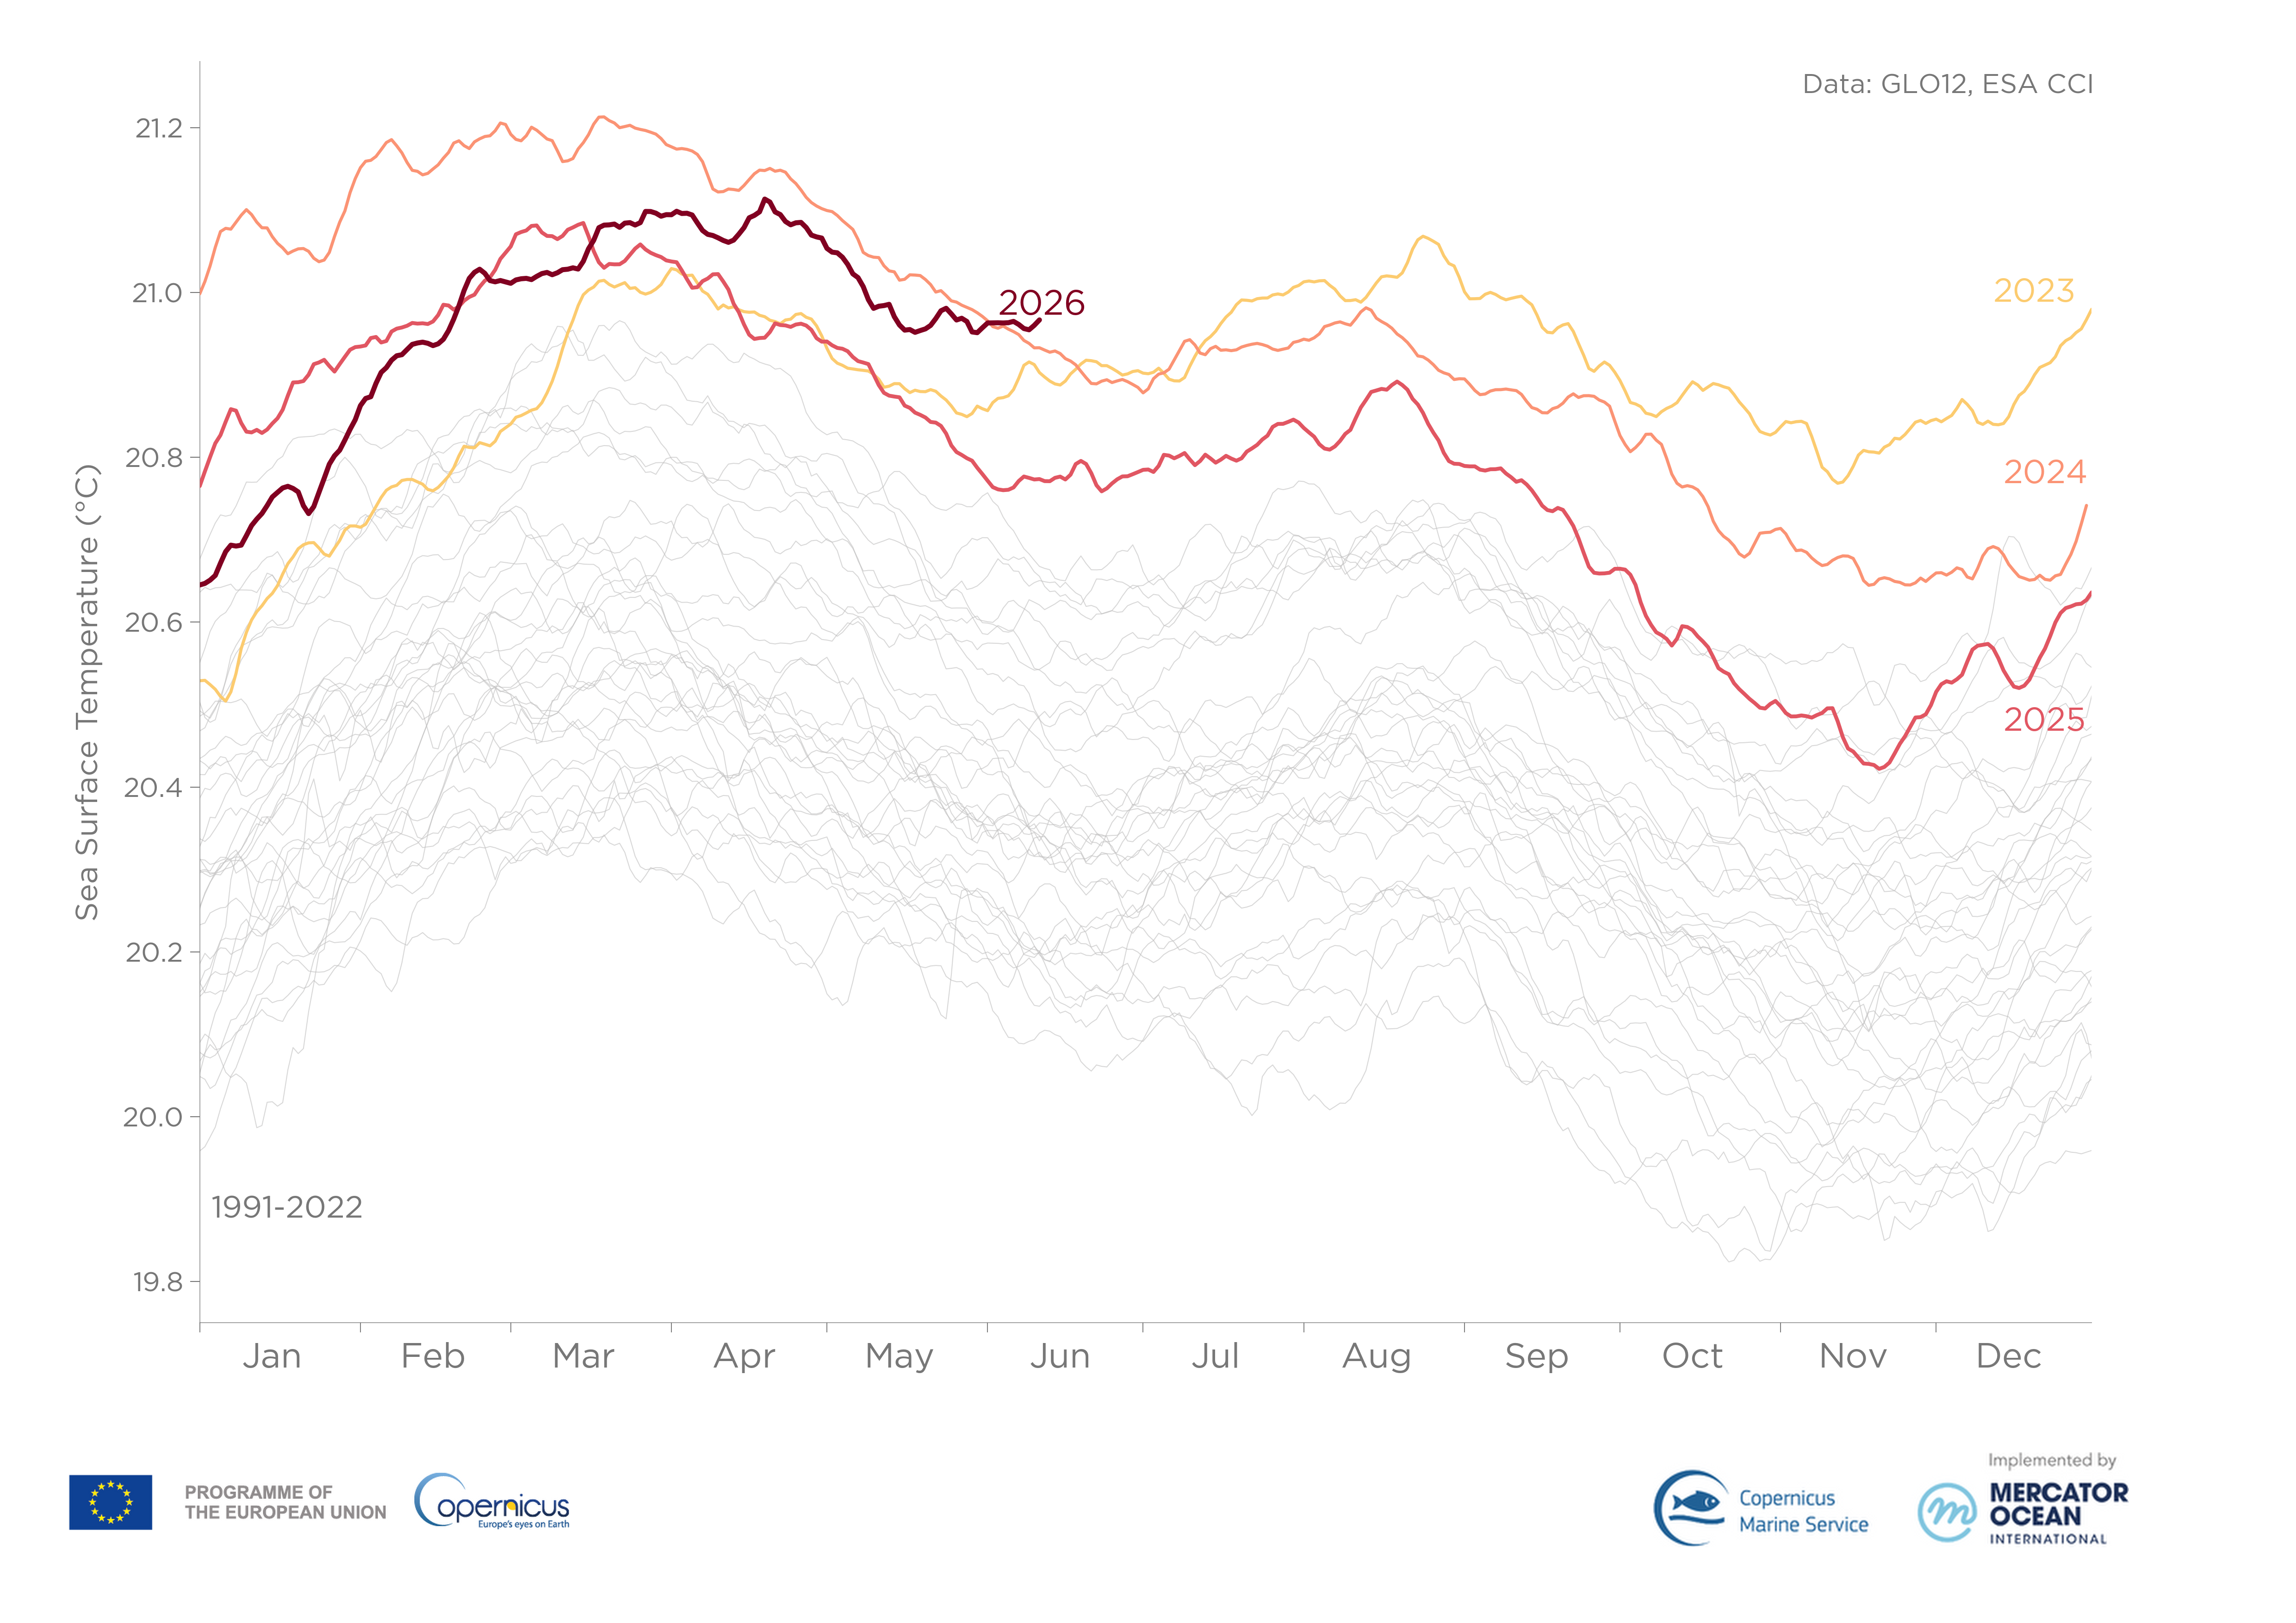

In [115]:
reference_fig, reference_ax = plot_reference_sst(combined)
reference_files = export_reference_figure(reference_fig)
plt.close(reference_fig)

preview_path = next(path for path in reference_files if path.suffix.lower() == '.png')
display(IPythonImage(filename=str(preview_path), width=4962 // PREVIEW_SCALE))


## 7. Export verification

This final cell checks the exact PNG dimensions and embedded DPI metadata required by the reference deliverable.


In [116]:
expected_size = (4962, 3507)
png_path = next(path for path in reference_files if path.suffix.lower() == '.png')

with Image.open(png_path) as image:
    actual_size = image.size
    actual_dpi = image.info.get('dpi', (None, None))

if actual_size != expected_size:
    raise AssertionError(f'Expected {expected_size}, obtained {actual_size}.')

if actual_dpi[0] is None or abs(actual_dpi[0] - EXPORT_DPI) > 0.1:
    raise AssertionError(f'Expected approximately {EXPORT_DPI} DPI, obtained {actual_dpi}.')

display(pd.DataFrame([{
    'file': png_path.name,
    'pixels': f'{actual_size[0]} × {actual_size[1]}',
    'dpi': round(actual_dpi[0], 2),
    'cut-off': combined['date'].max().strftime('%d %b %Y'),
    'font': GOTHAM_PROP.get_name(),
}]))
print('Reference PNG verified.')


,file,pixels,dpi,cut-off,font
0,SST timeseries_11June.png,4962 × 3507,300.0,11 Jun 2026,Gotham


Reference PNG verified.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
